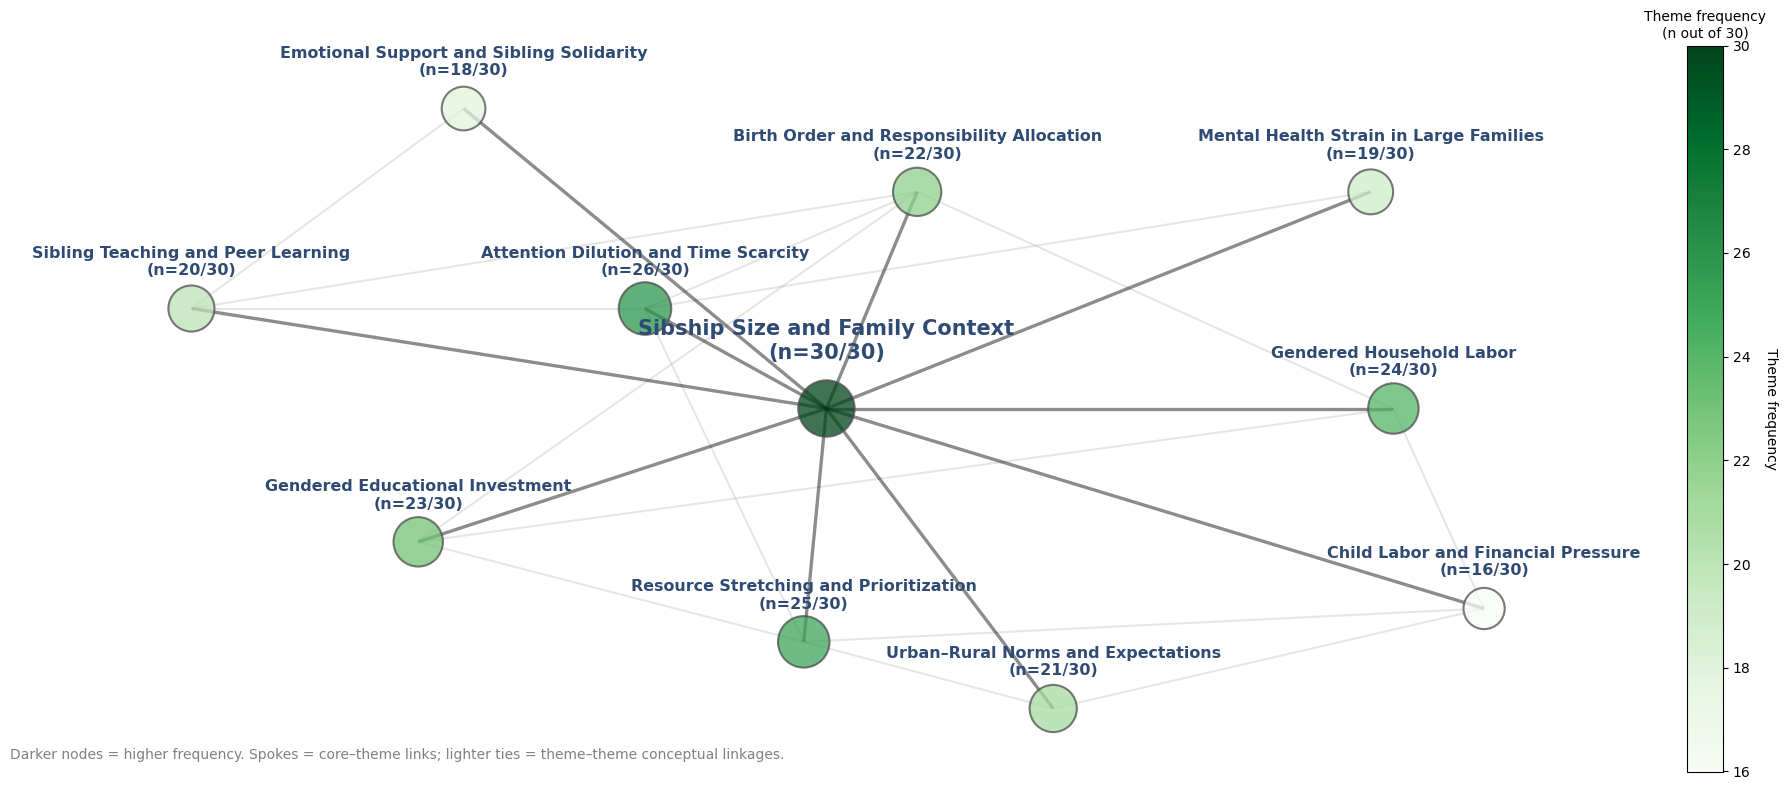

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# ----------------------------
# Theme frequencies
# ----------------------------
themes = {
    "Sibship Size and Family Context": 30,
    "Attention Dilution and Time Scarcity": 26,
    "Resource Stretching and Prioritization": 25,
    "Gendered Household Labor": 24,
    "Gendered Educational Investment": 23,
    "Birth Order and Responsibility Allocation": 22,
    "Urban–Rural Norms and Expectations": 21,
    "Sibling Teaching and Peer Learning": 20,
    "Mental Health Strain in Large Families": 19,
    "Emotional Support and Sibling Solidarity": 18,
    "Child Labor and Financial Pressure": 16
}

# ----------------------------
# Create graph
# ----------------------------
G = nx.Graph()

for theme, freq in themes.items():
    G.add_node(theme, freq=freq)

central = "Sibship Size and Family Context"

# Core spoke connections
spoke_edges = [
    (central,"Attention Dilution and Time Scarcity"),
    (central,"Resource Stretching and Prioritization"),
    (central,"Gendered Household Labor"),
    (central,"Gendered Educational Investment"),
    (central,"Birth Order and Responsibility Allocation"),
    (central,"Urban–Rural Norms and Expectations"),
    (central,"Sibling Teaching and Peer Learning"),
    (central,"Mental Health Strain in Large Families"),
    (central,"Emotional Support and Sibling Solidarity"),
    (central,"Child Labor and Financial Pressure"),
]

# Conceptual theme links
outer_edges = [
    ("Sibling Teaching and Peer Learning","Emotional Support and Sibling Solidarity"),
    ("Sibling Teaching and Peer Learning","Attention Dilution and Time Scarcity"),
    ("Sibling Teaching and Peer Learning","Birth Order and Responsibility Allocation"),
    ("Attention Dilution and Time Scarcity","Birth Order and Responsibility Allocation"),
    ("Attention Dilution and Time Scarcity","Mental Health Strain in Large Families"),
    ("Attention Dilution and Time Scarcity","Resource Stretching and Prioritization"),
    ("Birth Order and Responsibility Allocation","Gendered Household Labor"),
    ("Birth Order and Responsibility Allocation","Gendered Educational Investment"),
    ("Gendered Educational Investment","Resource Stretching and Prioritization"),
    ("Gendered Educational Investment","Gendered Household Labor"),
    ("Resource Stretching and Prioritization","Urban–Rural Norms and Expectations"),
    ("Resource Stretching and Prioritization","Child Labor and Financial Pressure"),
    ("Urban–Rural Norms and Expectations","Child Labor and Financial Pressure"),
    ("Gendered Household Labor","Child Labor and Financial Pressure")
]

for u,v in spoke_edges:
    G.add_edge(u,v,type="core")

for u,v in outer_edges:
    G.add_edge(u,v,type="concept")

# ----------------------------
# Node positions (manual layout)
# ----------------------------
pos = {
    "Sibship Size and Family Context": (0,0),
    "Emotional Support and Sibling Solidarity": (-0.8,0.9),
    "Sibling Teaching and Peer Learning": (-1.4,0.3),
    "Attention Dilution and Time Scarcity": (-0.4,0.3),
    "Gendered Educational Investment": (-0.9,-0.4),
    "Resource Stretching and Prioritization": (-0.05,-0.7),
    "Urban–Rural Norms and Expectations": (0.5,-0.9),
    "Birth Order and Responsibility Allocation": (0.2,0.65),
    "Mental Health Strain in Large Families": (1.2,0.65),
    "Gendered Household Labor": (1.25,0),
    "Child Labor and Financial Pressure": (1.45,-0.6)
}

# ----------------------------
# Node size and color
# ----------------------------
node_sizes = [themes[n]*55 for n in G.nodes()]
node_colors = [themes[n] for n in G.nodes()]

cmap = plt.cm.Greens
norm = Normalize(vmin=min(themes.values()), vmax=max(themes.values()))

# ----------------------------
# Create figure
# ----------------------------
fig, ax = plt.subplots(figsize=(18,8))

# Conceptual edges (lighter)
concept_edges = [(u,v) for u,v,d in G.edges(data=True) if d["type"]=="concept"]

nx.draw_networkx_edges(
    G,pos,
    edgelist=concept_edges,
    width=1.5,
    alpha=0.2,
    edge_color="gray",
    ax=ax
)

# Core edges (darker)
core_edges = [(u,v) for u,v,d in G.edges(data=True) if d["type"]=="core"]

nx.draw_networkx_edges(
    G,pos,
    edgelist=core_edges,
    width=2.4,
    alpha=0.45,
    edge_color="black",
    ax=ax
)

# Draw nodes
nodes = nx.draw_networkx_nodes(
    G,pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=cmap,
    vmin=min(themes.values()),
    vmax=max(themes.values()),
    edgecolors="#4d4d4d",
    linewidths=1.5,
    alpha=0.75,
    ax=ax
)

# ----------------------------
# Labels
# ----------------------------
for node,(x,y) in pos.items():
    freq = G.nodes[node]["freq"]
    label = f"{node}\n(n={freq}/30)"

    if node == central:
        ax.text(x,y+0.15,label,
        ha="center",fontsize=15,fontweight="bold",color="#2f4a73")
    else:
        ax.text(x,y+0.1,label,
        ha="center",fontsize=11.5,fontweight="bold",color="#2f4a73")

# ----------------------------
# Color legend
# ----------------------------
sm = ScalarMappable(norm=norm,cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm,ax=ax,fraction=0.025,pad=0.04)
cbar.set_label("Theme frequency",rotation=270,labelpad=20)
cbar.ax.set_title("Theme frequency\n(n out of 30)",fontsize=10)

# ----------------------------
# Footnote
# ----------------------------
ax.text(
-1.8,-1.05,
"Darker nodes = higher frequency. Spokes = core–theme links; lighter ties = theme–theme conceptual linkages.",
fontsize=10,color="gray"
)

ax.axis("off")

plt.tight_layout()

# ----------------------------
# Save figure
# ----------------------------
plt.savefig("thematic_network_figure.png",dpi=300,bbox_inches="tight")
plt.savefig("thematic_network_figure.pdf",dpi=300,bbox_inches="tight")

plt.show()
